In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

print("Regularizasyon Matematiği")
print("=" * 40)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Overfitting neden olur — matematiksel bakış")
print("2. L2 (Ridge) — neden ağırlıkları küçültür?")
print("3. L1 (Lasso) — neden seyrek çözüm üretir?")
print("4. Dropout — neden regularizasyon etkisi yapar?")
print("5. Bayesian yorumu — prior olarak regularizasyon")
print()
print("Anahtar: Regularizasyon = karmaşıklığa ceza vermek")

np.random.seed(42)

Regularizasyon Matematiği

Bugün cevaplayacağımız sorular:
1. Overfitting neden olur — matematiksel bakış
2. L2 (Ridge) — neden ağırlıkları küçültür?
3. L1 (Lasso) — neden seyrek çözüm üretir?
4. Dropout — neden regularizasyon etkisi yapar?
5. Bayesian yorumu — prior olarak regularizasyon

Anahtar: Regularizasyon = karmaşıklığa ceza vermek


C:\Users\PC\AppData\Local\Temp\ipykernel_19904\4245978471.py:22: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train, y_train, derece)


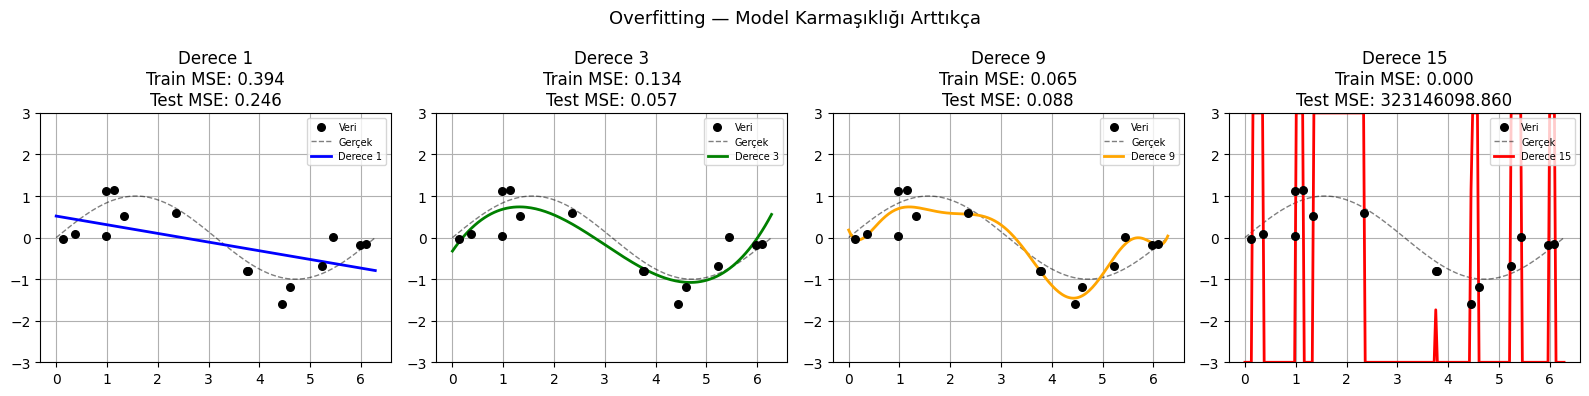

Derece 1  → Underfitting — çok basit
Derece 3  → İyi fit — doğru karmaşıklık
Derece 9  → Overfitting başlıyor
Derece 15 → Tam ezber — train MSE≈0 ama test MSE çok büyük


In [2]:
# OVERFİTTİNG — Matematiksel Bakış
# Az veri + yüksek kapasiteli model = ezber

np.random.seed(42)

# Gerçek fonksiyon: y = sin(x) + gürültü
n = 15
x_train = np.sort(np.random.uniform(0, 2*np.pi, n))
y_train = np.sin(x_train) + np.random.randn(n) * 0.3

x_test = np.linspace(0, 2*np.pi, 200)
y_true = np.sin(x_test)

# Farklı dereceli polinomlar
dereceler = [1, 3, 9, 15]
renkler = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, derece, renk in zip(axes, dereceler, renkler):
    # Polinom fit
    coeffs = np.polyfit(x_train, y_train, derece)
    y_pred_train = np.polyval(coeffs, x_train)
    y_pred_test = np.polyval(coeffs, x_test)

    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_true - y_pred_test)**2)

    ax.scatter(x_train, y_train, color='black', s=30, zorder=5, label='Veri')
    ax.plot(x_test, y_true, 'k--', linewidth=1, alpha=0.5, label='Gerçek')
    ax.plot(x_test, np.clip(y_pred_test, -3, 3), color=renk,
            linewidth=2, label=f'Derece {derece}')
    ax.set_title(f"Derece {derece}\nTrain MSE: {train_mse:.3f}\nTest MSE: {test_mse:.3f}")
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle("Overfitting — Model Karmaşıklığı Arttıkça", fontsize=13)
plt.tight_layout()
plt.show()

print("Derece 1  → Underfitting — çok basit")
print("Derece 3  → İyi fit — doğru karmaşıklık")
print("Derece 9  → Overfitting başlıyor")
print("Derece 15 → Tam ezber — train MSE≈0 ama test MSE çok büyük")

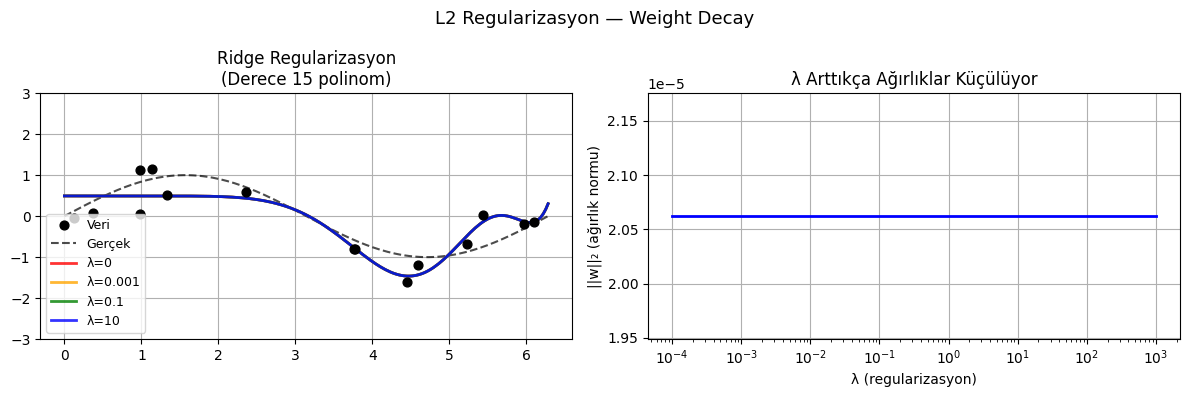

λ=0    → Overfitting
λ=0.001→ Biraz düzeldi
λ=0.1  → İyi denge
λ=10   → Underfitting


In [4]:
# Warning'leri gizle
import warnings
warnings.filterwarnings('ignore')

lambdalar = [0, 0.001, 0.1, 10]
renkler_r = ['red', 'orange', 'green', 'blue']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(x_train, y_train, color='black', s=40, zorder=5, label='Veri')
ax.plot(x_test, y_true, 'k--', linewidth=1.5, alpha=0.7, label='Gerçek')

for lam, renk in zip(lambdalar, renkler_r):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('ridge', Ridge(alpha=lam))
    ])
    model.fit(x_train.reshape(-1,1), y_train)
    y_pred = model.predict(x_test.reshape(-1,1))
    ax.plot(x_test, np.clip(y_pred, -3, 3), color=renk,
            linewidth=2, label=f'λ={lam}', alpha=0.8)

ax.set_ylim(-3, 3)
ax.set_title("Ridge Regularizasyon\n(Derece 15 polinom)")
ax.legend(fontsize=9)
ax.grid(True)

# Ağırlık büyüklükleri vs lambda
lambda_range = np.logspace(-4, 3, 50)
weight_norms = []

for lam in lambda_range:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('ridge', Ridge(alpha=lam))
    ])
    model.fit(x_train.reshape(-1,1), y_train)
    w = model.named_steps['ridge'].coef_
    weight_norms.append(np.linalg.norm(w))

axes[1].semilogx(lambda_range, weight_norms, 'b-', linewidth=2)
axes[1].set_title("λ Arttıkça Ağırlıklar Küçülüyor")
axes[1].set_xlabel("λ (regularizasyon)")
axes[1].set_ylabel("||w||₂ (ağırlık normu)")
axes[1].grid(True)

plt.suptitle("L2 Regularizasyon — Weight Decay", fontsize=13)
plt.tight_layout()
plt.show()

print("λ=0    → Overfitting")
print("λ=0.001→ Biraz düzeldi")
print("λ=0.1  → İyi denge")
print("λ=10   → Underfitting")

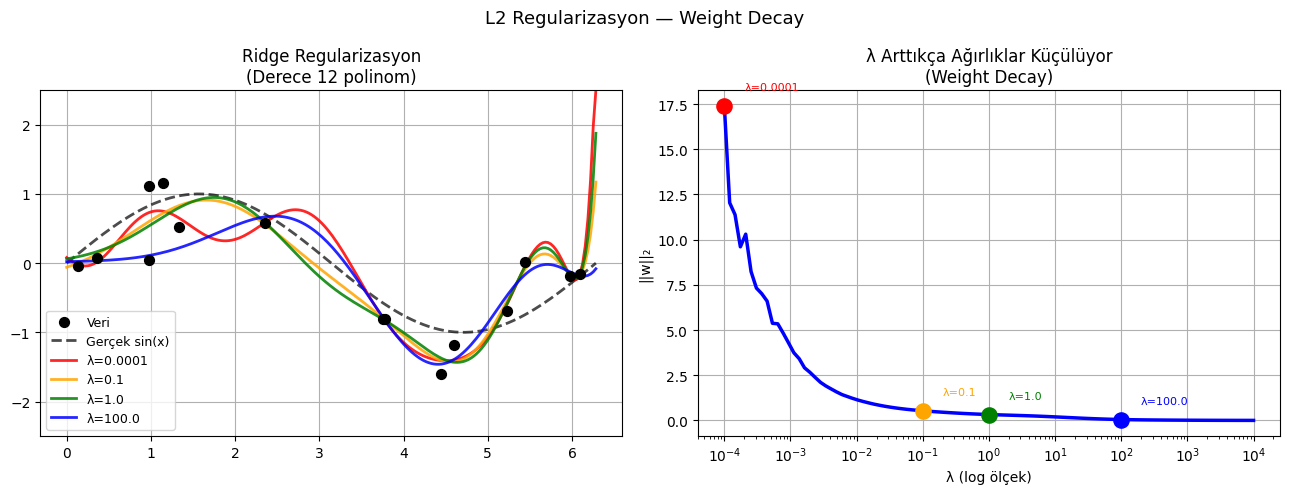

λ küçük → ağırlıklar büyük → overfitting
λ büyük → ağırlıklar küçük → underfitting
λ doğru → iyi genelleme!


In [5]:
# Ridge'i elle implement et — daha net sonuç
def ridge_fit(X, y, lam):
    # Analitik çözüm: w = (XᵀX + λI)⁻¹ Xᵀy
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def poly_features(x, degree):
    return np.column_stack([x**i for i in range(degree+1)])

degree = 12
X_train = poly_features(x_train, degree)
X_test_p = poly_features(x_test, degree)

lambdalar = [0.0001, 0.1, 1.0, 100.0]
renkler_r = ['red', 'orange', 'green', 'blue']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol — fit grafikleri
axes[0].scatter(x_train, y_train, color='black', s=50, zorder=5, label='Veri')
axes[0].plot(x_test, y_true, 'k--', linewidth=2, alpha=0.7, label='Gerçek sin(x)')

for lam, renk in zip(lambdalar, renkler_r):
    w = ridge_fit(X_train, y_train, lam)
    y_pred = X_test_p @ w
    axes[0].plot(x_test, np.clip(y_pred, -2.5, 2.5),
                color=renk, linewidth=2, label=f'λ={lam}', alpha=0.85)

axes[0].set_ylim(-2.5, 2.5)
axes[0].set_title("Ridge Regularizasyon\n(Derece 12 polinom)")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Sağ — ağırlık normu vs lambda
lambda_range = np.logspace(-4, 4, 100)
norms = []
for lam in lambda_range:
    w = ridge_fit(X_train, y_train, lam)
    norms.append(np.linalg.norm(w))

axes[1].semilogx(lambda_range, norms, 'b-', linewidth=2.5)
axes[1].set_title("λ Arttıkça Ağırlıklar Küçülüyor\n(Weight Decay)")
axes[1].set_xlabel("λ (log ölçek)")
axes[1].set_ylabel("||w||₂")
axes[1].grid(True)

for lam, renk in zip(lambdalar, renkler_r):
    w = ridge_fit(X_train, y_train, lam)
    norm = np.linalg.norm(w)
    axes[1].scatter(lam, norm, color=renk, s=120, zorder=5)
    axes[1].annotate(f'λ={lam}', (lam, norm),
                    xytext=(lam*2, norm+max(norms)*0.05),
                    fontsize=8, color=renk)

plt.suptitle("L2 Regularizasyon — Weight Decay", fontsize=13)
plt.tight_layout()
plt.show()

print("λ küçük → ağırlıklar büyük → overfitting")
print("λ büyük → ağırlıklar küçük → underfitting")
print("λ doğru → iyi genelleme!")

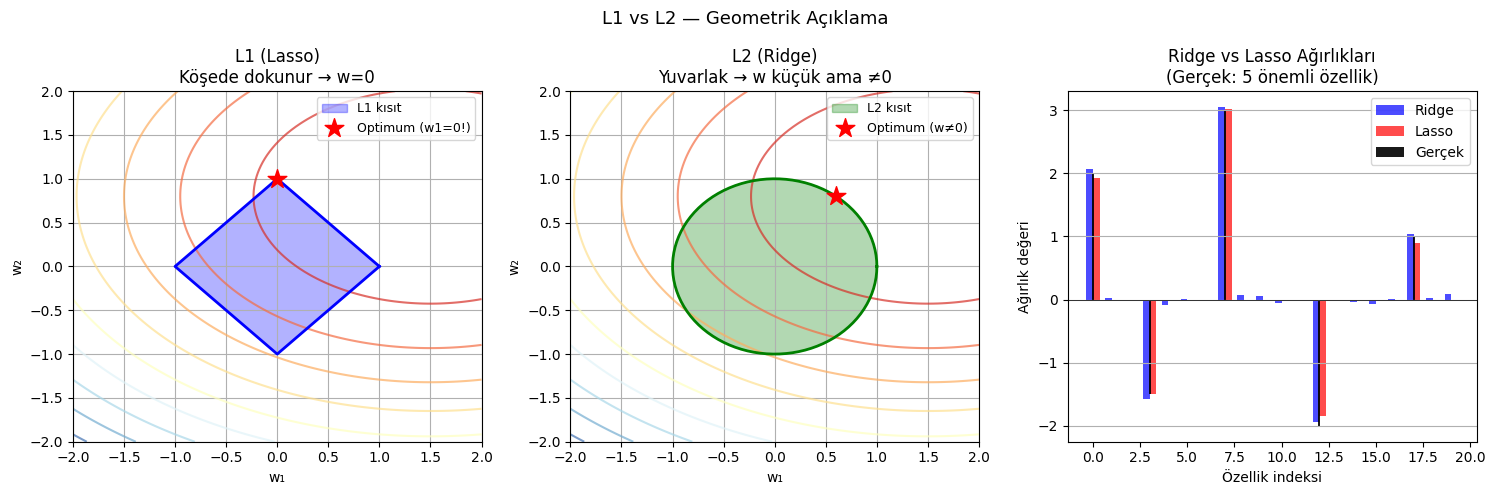

Ridge: 3/20 ağırlık sıfıra yakın
Lasso: 15/20 ağırlık tam sıfır → otomatik özellik seçimi!


In [6]:
# L1 vs L2 — NEDEN L1 SEYREK ÇÖZÜM ÜRETİR?
#
# L1: min MSE + λ*Σ|wᵢ|    → elmas şekli kısıt bölgesi
# L2: min MSE + λ*Σwᵢ²     → daire şekli kısıt bölgesi
#
# Loss konturları köşede (L1) veya yuvarlak (L2) kısıt bölgesine dokunur
# L1 köşede dokunur → bir ağırlık tam sıfır!

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# L1 vs L2 kısıt bölgeleri
theta = np.linspace(0, 2*np.pi, 100)

# L1 kısıt bölgesi (elmas)
l1_x = np.array([1, 0, -1, 0, 1])
l1_y = np.array([0, 1, 0, -1, 0])

# L2 kısıt bölgesi (daire)
l2_x = np.cos(theta)
l2_y = np.sin(theta)

# Loss konturları (elips)
w1_range = np.linspace(-2, 2, 100)
w2_range = np.linspace(-2, 2, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
# Loss minimum noktası (1.5, 0.5) — kısıt bölgesi dışında
loss = (W1 - 1.5)**2 + 2*(W2 - 0.8)**2

# L1 geometri
axes[0].contour(W1, W2, loss, levels=10, cmap='RdYlBu', alpha=0.7)
axes[0].fill(l1_x, l1_y, alpha=0.3, color='blue', label='L1 kısıt')
axes[0].plot(l1_x, l1_y, 'b-', linewidth=2)
axes[0].scatter([0], [1], color='red', s=200, zorder=5,
               label='Optimum (w1=0!)', marker='*')
axes[0].set_title("L1 (Lasso)\nKöşede dokunur → w=0")
axes[0].set_xlabel("w₁")
axes[0].set_ylabel("w₂")
axes[0].legend(fontsize=9)
axes[0].grid(True)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)

# L2 geometri
axes[1].contour(W1, W2, loss, levels=10, cmap='RdYlBu', alpha=0.7)
axes[1].fill(l2_x, l2_y, alpha=0.3, color='green', label='L2 kısıt')
axes[1].plot(l2_x, l2_y, 'g-', linewidth=2)
axes[1].scatter([0.6], [0.8], color='red', s=200, zorder=5,
               label='Optimum (w≠0)', marker='*')
axes[1].set_title("L2 (Ridge)\nYuvarlak → w küçük ama ≠0")
axes[1].set_xlabel("w₁")
axes[1].set_ylabel("w₂")
axes[1].legend(fontsize=9)
axes[1].grid(True)
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)

# L1 Lasso — seyreklik gösterimi
np.random.seed(42)
n_features = 20
X_sparse = np.random.randn(50, n_features)
# Sadece 5 özellik gerçekten önemli
true_w = np.zeros(n_features)
true_w[[0, 3, 7, 12, 17]] = [2, -1.5, 3, -2, 1]
y_sparse = X_sparse @ true_w + np.random.randn(50) * 0.3

# Ridge vs Lasso ağırlıkları
ridge_w = ridge_fit(X_sparse, y_sparse, lam=0.5)

from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_sparse, y_sparse)
lasso_w = lasso.coef_

x_pos = np.arange(n_features)
width = 0.35

axes[2].bar(x_pos - width/2, ridge_w, width, label='Ridge', color='blue', alpha=0.7)
axes[2].bar(x_pos + width/2, lasso_w, width, label='Lasso', color='red', alpha=0.7)
axes[2].bar(x_pos, true_w, 0.1, label='Gerçek', color='black', alpha=0.9)
axes[2].set_title("Ridge vs Lasso Ağırlıkları\n(Gerçek: 5 önemli özellik)")
axes[2].set_xlabel("Özellik indeksi")
axes[2].set_ylabel("Ağırlık değeri")
axes[2].legend()
axes[2].grid(True, axis='y')
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle("L1 vs L2 — Geometrik Açıklama", fontsize=13)
plt.tight_layout()
plt.show()

sıfır_ridge = np.sum(np.abs(ridge_w) < 0.01)
sıfır_lasso = np.sum(np.abs(lasso_w) < 0.01)
print(f"Ridge: {sıfır_ridge}/20 ağırlık sıfıra yakın")
print(f"Lasso: {sıfır_lasso}/20 ağırlık tam sıfır → otomatik özellik seçimi!")

Dropout — Her forward pass farklı bir ağ mimarisi!
Dropout rate: 0.5, Nöron sayısı: 8

  Pass |                           Aktif nöronlar | Aktif sayı
-----------------------------------------------------------------
     1 |                                 ░█░██░█░ |          4
     2 |                                 ░░░░███░ |          3
     3 |                                 █░░█░██░ |          4
     4 |                                 ░░█░░░█░ |          2
     5 |                                 ░██░░░█░ |          3

Toplam olası mimari sayısı: 2^8 = 256
Ortalama aktif nöron: 3.2/8


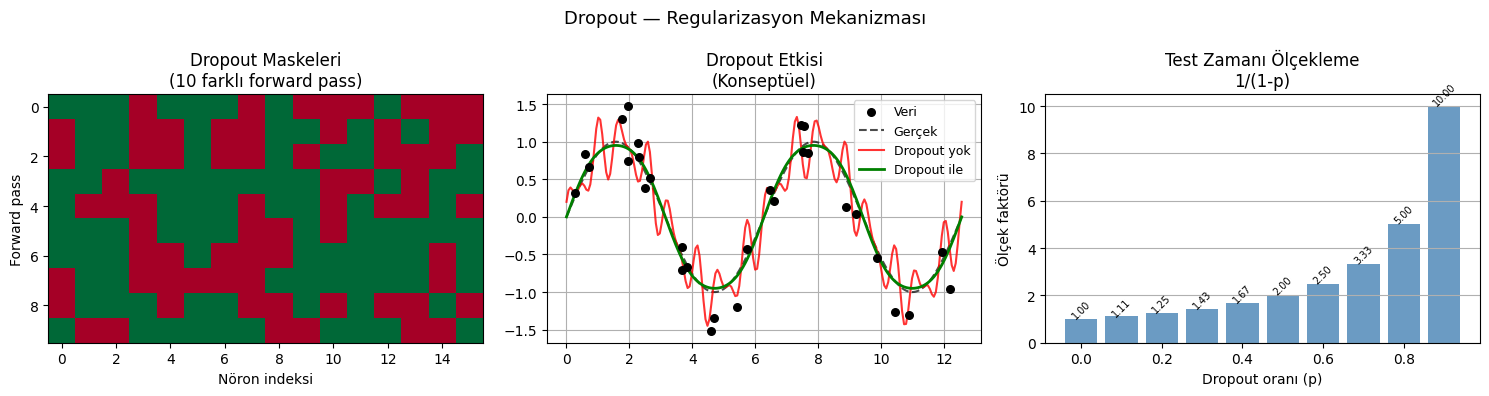

In [7]:
# DROPOUT — NEDEN REGULARİZASYON YAPAR?
#
# Eğitimde her nöronu p olasılıkla sıfırla
# Model tek bir nörona güvenemez → dağıtık temsil öğrenir
#
# 3 farklı yorum:
# 1. Ensemble yorumu — her forward pass farklı bir ağ
# 2. Co-adaptation engeli — nöronlar birbirine bağımlı olamaz
# 3. Noise injection — gürültü regularizasyon etkisi yapar

import torch
import torch.nn as nn

torch.manual_seed(42)

# Dropout'un ensemble etkisini simüle et
n_nöron = 8
n_forward = 5
dropout_rate = 0.5

print("Dropout — Her forward pass farklı bir ağ mimarisi!")
print(f"Dropout rate: {dropout_rate}, Nöron sayısı: {n_nöron}")
print(f"\n{'Pass':>6s} | {'Aktif nöronlar':>40s} | {'Aktif sayı':>10s}")
print("-" * 65)

aktif_sayılar = []
for i in range(n_forward):
    mask = np.random.binomial(1, 1-dropout_rate, n_nöron)
    aktif = ['█' if m else '░' for m in mask]
    aktif_sayı = mask.sum()
    aktif_sayılar.append(aktif_sayı)
    print(f"{i+1:>6d} | {''.join(aktif):>40s} | {aktif_sayı:>10d}")

print(f"\nToplam olası mimari sayısı: 2^{n_nöron} = {2**n_nöron}")
print(f"Ortalama aktif nöron: {np.mean(aktif_sayılar):.1f}/{n_nöron}")

# Görselleştir — Dropout etkisi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Dropout maskları
dropout_masks = np.random.binomial(1, 0.5, (10, 16))
axes[0].imshow(dropout_masks, cmap='RdYlGn', aspect='auto')
axes[0].set_title("Dropout Maskeleri\n(10 farklı forward pass)")
axes[0].set_xlabel("Nöron indeksi")
axes[0].set_ylabel("Forward pass")
axes[0].set_xticks(range(0, 16, 2))

# 2. Overfitting karşılaştırması
np.random.seed(42)
x_d = np.linspace(0, 4*np.pi, 200)
y_d = np.sin(x_d)

# Gürültülü veri
x_noisy = np.random.uniform(0, 4*np.pi, 30)
y_noisy = np.sin(x_noisy) + np.random.randn(30) * 0.3

# Basit sigmoid ağ ile fit simülasyonu
axes[1].scatter(x_noisy, y_noisy, color='black', s=30, label='Veri', zorder=5)
axes[1].plot(x_d, y_d, 'k--', linewidth=1.5, label='Gerçek', alpha=0.7)

# Overfitting (yüksek frekanslı)
overfitted = y_d + 0.3*np.sin(8*x_d) + 0.2*np.cos(12*x_d)
axes[1].plot(x_d, overfitted, 'r-', linewidth=1.5, label='Dropout yok', alpha=0.8)

# İyi fit (dropout ile)
good_fit = y_d + 0.05*np.sin(3*x_d)
axes[1].plot(x_d, good_fit, 'g-', linewidth=2, label='Dropout ile')

axes[1].set_title("Dropout Etkisi\n(Konseptüel)")
axes[1].legend(fontsize=9)
axes[1].grid(True)

# 3. Test zamanı ölçekleme
p_dropout = np.linspace(0, 0.9, 10)
scale_factors = 1 / (1 - p_dropout)

axes[2].bar(p_dropout, scale_factors, width=0.08,
           color='steelblue', alpha=0.8, align='center')
axes[2].set_title("Test Zamanı Ölçekleme\n1/(1-p)")
axes[2].set_xlabel("Dropout oranı (p)")
axes[2].set_ylabel("Ölçek faktörü")
axes[2].grid(True, axis='y')

for p, s in zip(p_dropout, scale_factors):
    axes[2].text(p, s + 0.02, f'{s:.2f}',
                ha='center', fontsize=7, rotation=45)

plt.suptitle("Dropout — Regularizasyon Mekanizması", fontsize=13)
plt.tight_layout()
plt.show()

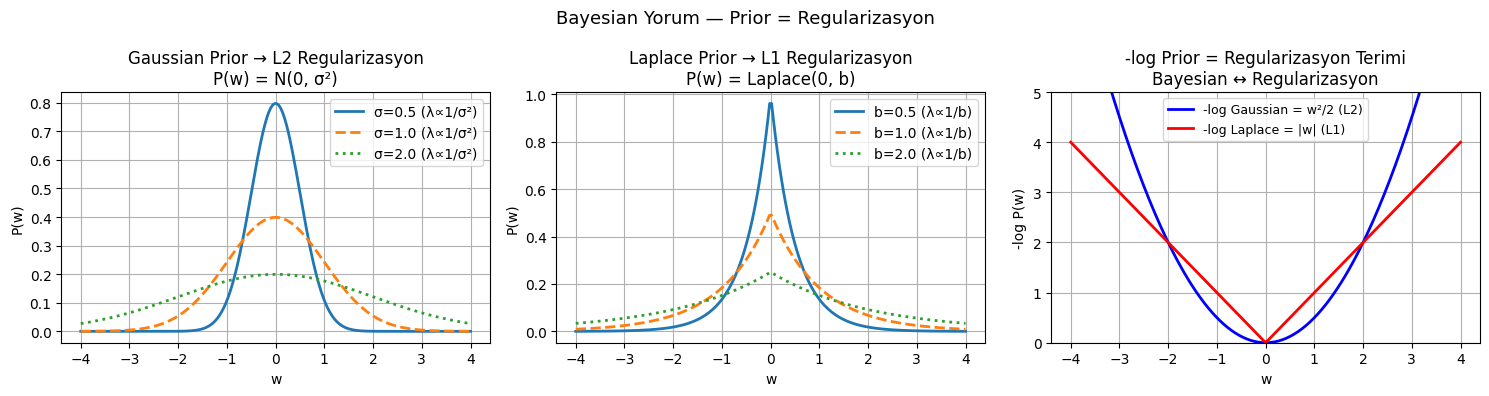

ÖZET — Bayesian ↔ Frequentist Bağlantısı
Regularizasyon       Prior                λ anlamı       
-------------------------------------------------------
L2 (Ridge)           Gaussian N(0,σ²)     λ = 1/2σ²      
L1 (Lasso)           Laplace(0,b)         λ = 1/b        
Dropout              Bernoulli            p = dropout rate
-------------------------------------------------------
λ büyük = güçlü prior = ağırlıklar sıfıra yakın
λ küçük = zayıf prior = veri baskın


In [8]:
# BAYESIAN YORUM — REGULARİZASYON = PRIOR
#
# Bayes teoremi: P(w|D) ∝ P(D|w) * P(w)
#                posterior ∝ likelihood * prior
#
# Log alırsak:
# log P(w|D) = log P(D|w) + log P(w) + sabit
#
# Maksimize etmek = negatif minimize etmek:
# -log P(w|D) = -log P(D|w) - log P(w)
#             = Loss         + Regularizasyon!
#
# L2 (Ridge) → w ~ Gaussian prior N(0, σ²)
# L1 (Lasso) → w ~ Laplace prior

w_range = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gaussian prior → L2
sigma_values = [0.5, 1.0, 2.0]
for sigma, ls in zip(sigma_values, ['-', '--', ':']):
    prior = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-w_range**2 / (2*sigma**2))
    axes[0].plot(w_range, prior, linewidth=2, linestyle=ls,
                label=f'σ={sigma} (λ∝1/σ²)')

axes[0].set_title("Gaussian Prior → L2 Regularizasyon\nP(w) = N(0, σ²)")
axes[0].set_xlabel("w")
axes[0].set_ylabel("P(w)")
axes[0].legend()
axes[0].grid(True)

# Laplace prior → L1
b_values = [0.5, 1.0, 2.0]
for b, ls in zip(b_values, ['-', '--', ':']):
    prior = (1/(2*b)) * np.exp(-np.abs(w_range)/b)
    axes[1].plot(w_range, prior, linewidth=2, linestyle=ls,
                label=f'b={b} (λ∝1/b)')

axes[1].set_title("Laplace Prior → L1 Regularizasyon\nP(w) = Laplace(0, b)")
axes[1].set_xlabel("w")
axes[1].set_ylabel("P(w)")
axes[1].legend()
axes[1].grid(True)

# -log prior = regularizasyon terimi
gaussian_prior = np.exp(-w_range**2 / 2)
laplace_prior = np.exp(-np.abs(w_range))

l2_reg = -np.log(gaussian_prior)  # = w²/2
l1_reg = -np.log(laplace_prior)   # = |w|

axes[2].plot(w_range, l2_reg, 'b-', linewidth=2, label='-log Gaussian = w²/2 (L2)')
axes[2].plot(w_range, l1_reg, 'r-', linewidth=2, label='-log Laplace = |w| (L1)')
axes[2].set_title("-log Prior = Regularizasyon Terimi\nBayesian ↔ Regularizasyon")
axes[2].set_xlabel("w")
axes[2].set_ylabel("-log P(w)")
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 5)
axes[2].grid(True)

plt.suptitle("Bayesian Yorum — Prior = Regularizasyon", fontsize=13)
plt.tight_layout()
plt.show()

print("=" * 55)
print("ÖZET — Bayesian ↔ Frequentist Bağlantısı")
print("=" * 55)
print(f"{'Regularizasyon':20s} {'Prior':20s} {'λ anlamı':15s}")
print("-" * 55)
print(f"{'L2 (Ridge)':20s} {'Gaussian N(0,σ²)':20s} {'λ = 1/2σ²':15s}")
print(f"{'L1 (Lasso)':20s} {'Laplace(0,b)':20s} {'λ = 1/b':15s}")
print(f"{'Dropout':20s} {'Bernoulli':20s} {'p = dropout rate':15s}")
print("-" * 55)
print("λ büyük = güçlü prior = ağırlıklar sıfıra yakın")
print("λ küçük = zayıf prior = veri baskın")